# Random Forest max_depth

In [7]:
from sklearn.neighbors import KNeighborsClassifier

In [8]:
# ---- class_weight comparison: does weighting the minority class reduce false negatives? ----
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, recall_score
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [9]:
# Rebuild X, y (Amyloid + Total tau, MCI only) — same as cell 45
df = pd.read_csv("data/plasma_lipidomics.csv")

In [10]:
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy()
amyloid_median = mci['CSF Amyloid (pg/mL)'].median()
mci['CSF Amyloid (pg/mL)'] = mci['CSF Amyloid (pg/mL)'].fillna(amyloid_median)
tau_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(tau_median)

mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)']]

print("Class balance (0=No progression, 1=Progressed):")
print(y.value_counts(), "\n")

Class balance (0=No progression, 1=Progressed):
target
1    47
0    42
Name: count, dtype: int64 



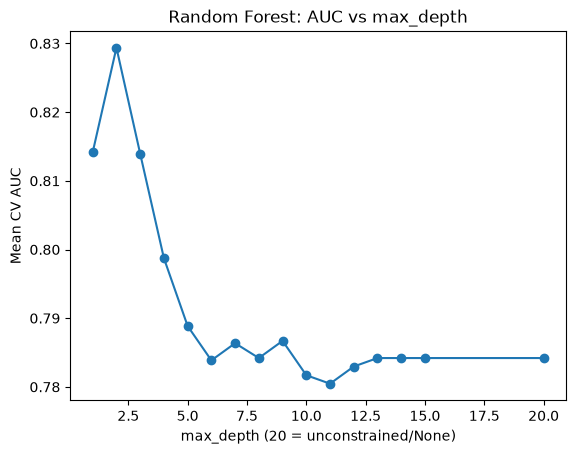

In [13]:
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
depth_range = list(range(1, 16)) + [None]  # None = unconstrained
rf_scores = []
for d in depth_range:
    rf = RandomForestClassifier(n_estimators=300, max_depth=d, random_state=42)
    score = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
    rf_scores.append(score.mean())

# plot with None relabeled to a numeric placeholder (e.g. 20) for the x-axis
x_vals = [d if d is not None else 20 for d in depth_range]
plt.plot(x_vals, rf_scores, marker='o')
plt.xlabel('max_depth (20 = unconstrained/None)')
plt.ylabel('Mean CV AUC')
plt.title('Random Forest: AUC vs max_depth')
plt.savefig(f"images/max_depth", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
data = {
    'Depth':x_vals,
    'AUC': rf_scores,
}

# Create DataFrame
df = pd.DataFrame(data)

In [16]:
df

,Depth,AUC
0,1,0.814167
1,2,0.829383
2,3,0.813951
3,4,0.798735
4,5,0.788858
5,6,0.783858
6,7,0.786358
7,8,0.784198
8,9,0.786698
9,10,0.781698
